Loaded 1120 samples × 24 CPU cores


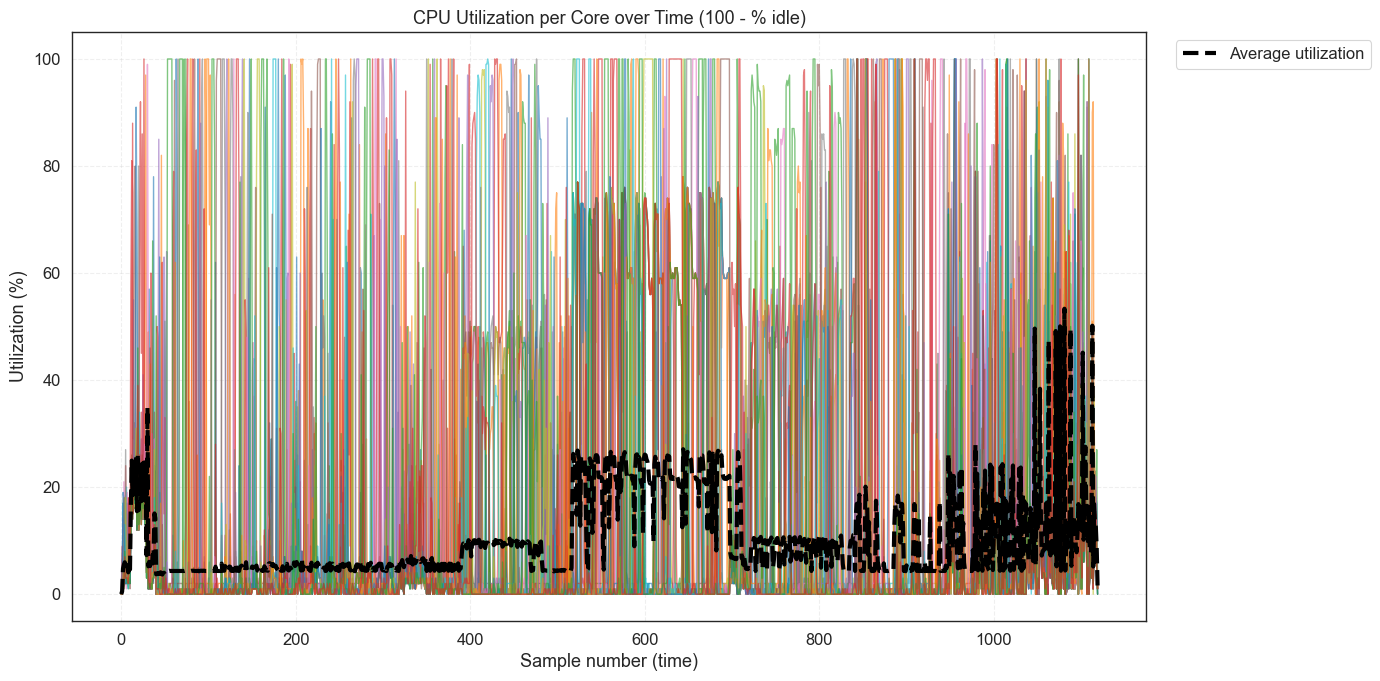


Utilization summary (mean per core):
util_cpu0         6.6
util_cpu1        16.5
util_cpu2        14.1
util_cpu3        18.0
util_cpu4        11.6
util_cpu5        11.7
util_cpu6        10.5
util_cpu7        10.3
util_cpu8         8.6
util_cpu9         9.2
util_cpu10       10.6
util_cpu11        6.4
util_cpu12       12.6
util_cpu13        9.5
util_cpu14        8.6
util_cpu15       12.5
util_cpu16        9.0
util_cpu17       10.7
util_cpu18        8.6
util_cpu19        6.6
util_cpu20        5.5
util_cpu21       10.1
util_cpu22       11.3
util_cpu23       11.9
avg_all_cores    10.5
dtype: float64

Overall average utilization: 10.5%


In [27]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# ───────────────────────────────────────────────
# Parse the file (same as the working method)
# ───────────────────────────────────────────────
filename = "vm2-report_cpu.out"   # ← change if needed

data = []
with open(filename, 'r') as f:
    for line in f:
        line = line.rstrip()
        if not line or line.startswith(('You did', '-----', 'usr sys')):
            continue
        if '|' in line:
            line = line.split('|', 1)[0]

        # Extract all groups of 5 integers
        matches = re.findall(r'\d+\s+\d+\s+\d+\s+\d+\s+\d+', line)
        if not matches:
            continue

        idls = []
        for group in matches:
            parts = re.split(r'\s+', group.strip())
            if len(parts) == 5:
                idls.append(int(parts[2]))  # idl is 3rd value (0-based index 2)

        if idls:
            data.append(idls)

# Build DataFrame with idle values
if not data:
    raise ValueError("No valid data lines found in the file.")

n_cpus = len(data[0])
df_idl = pd.DataFrame(data, columns=[f"idl_cpu{i}" for i in range(n_cpus)])

print(f"Loaded {len(df_idl)} samples × {n_cpus} CPU cores")

# Compute utilization = 100 - idle
df_util = 100 - df_idl
df_util.columns = [f"util_cpu{i}" for i in range(n_cpus)]

# Optional: add average utilization across all cores
df_util['avg_all_cores'] = df_util.mean(axis=1)

# ───────────────────────────────────────────────
# Plot: line plot for every CPU core's utilization
# ───────────────────────────────────────────────
plt.figure(figsize=(14, 7))

# Plot individual cores (light/thin lines so they don't overwhelm)
for col in df_util.columns[:-1]:  # exclude avg for now
    plt.plot(df_util.index, df_util[col], 
             linewidth=1.0, alpha=0.6, 
             label=col if n_cpus <= 12 else None)  # legend only if few cores

# Highlight the average with a bold line
plt.plot(df_util.index, df_util['avg_all_cores'],
         color='black', linewidth=3, linestyle='--',
         label='Average utilization (all cores)')

plt.title("CPU Utilization per Core over Time (100 - % idle)")
plt.xlabel("Sample number (time)")
plt.ylabel("Utilization (%)")
plt.grid(True, alpha=0.3, linestyle='--')

# Legend handling
if n_cpus <= 12:
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
else:
    plt.legend([plt.Line2D([0], [0], color='black', lw=3, ls='--')], 
               ['Average utilization'], 
               bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Optional: also print summary statistics
print("\nUtilization summary (mean per core):")
print(df_util.mean().round(1))
print(f"\nOverall average utilization: {df_util['avg_all_cores'].mean():.1f}%")

Loaded: 1,120 samples × 24 cores
Average utilization across all cores and time: 10.6%


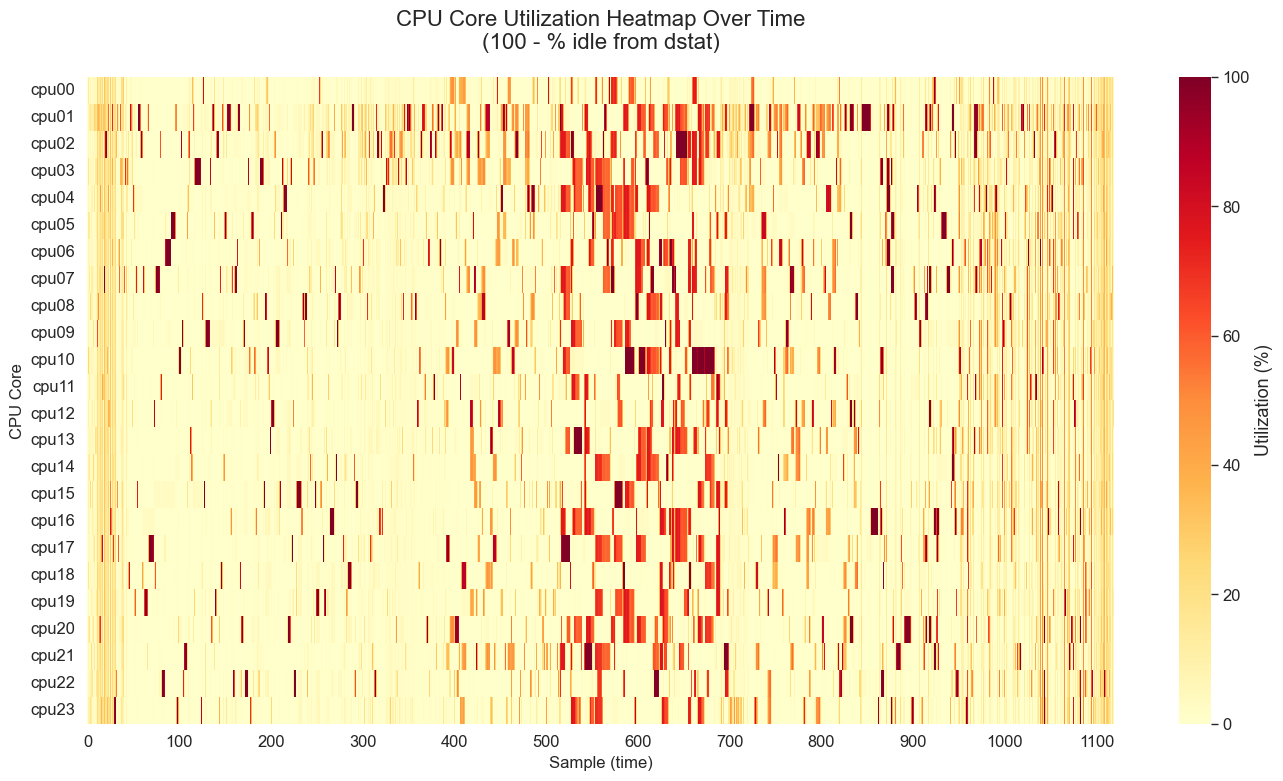

In [22]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ───────────────────────────────────────────────
# Parse dstat output → utilization DataFrame
# ───────────────────────────────────────────────
def parse_dstat_to_utilization(filename):
    data = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.rstrip()
            if not line or line.startswith(('You did', '-----', 'usr sys')):
                continue
            if '|' in line:
                line = line.split('|', 1)[0]
            matches = re.findall(r'\d+\s+\d+\s+\d+\s+\d+\s+\d+', line)
            if not matches:
                continue
            idls = [int(re.split(r'\s+', group.strip())[2]) for group in matches]
            if idls:
                data.append(idls)

    if not data:
        raise ValueError(f"No valid data found in {filename}")

    n_cores = len(data[0])
    df_idl = pd.DataFrame(data, columns=[f"cpu{i:02d}" for i in range(n_cores)])
    df_util = 100 - df_idl.astype(float)

    print(f"Loaded: {df_util.shape[0]:,} samples × {n_cores} cores")
    print(f"Average utilization across all cores and time: {df_util.values.mean():.1f}%")

    return df_util


# ───────────────────────────────────────────────
# Create the exact heatmap style you requested
# ───────────────────────────────────────────────
def plot_heatmap_as_requested(df_util, filename_for_save='cpu_util_heatmap'):
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        df_util.T,                      # Transpose: time on x, cores on y
        cmap="YlOrRd",                  # yellow → red = low → high utilization
        cbar_kws={'label': 'Utilization (%)'},
        linewidths=0,                   # clean look, no cell borders
        xticklabels=100,                # show every 100th sample to avoid clutter
        rasterized=True                 # better for large matrices + export
    )
    plt.title('CPU Core Utilization Heatmap Over Time\n(100 - % idle from dstat)', 
              fontsize=16, pad=20)
    plt.xlabel('Sample (time)', fontsize=12)
    plt.ylabel('CPU Core', fontsize=12)
    plt.tight_layout()
    
    # Save high-resolution versions
    plt.savefig(f'{filename_for_save}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{filename_for_save}.pdf', bbox_inches='tight')  # vector format
    plt.show()


# ───────────────────────────────────────────────
# Run it
# ───────────────────────────────────────────────
if __name__ == "__main__":
    filename = "vm1-report_cpu.out"          # ← your file

    df_util = parse_dstat_to_utilization(filename)
    
    plot_heatmap_as_requested(
        df_util,
        filename_for_save="cpu_util_heatmap_publication"
    )

VM1: 1,120 samples × 24 cores
VM2: 1,120 samples × 24 cores
VM3: 1,120 samples × 24 cores


/var/folders/r9/__77n3l10hx8wssbjz98yl3m0000gn/T/ipykernel_36341/853524309.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1.0])  # leave space for colorbar


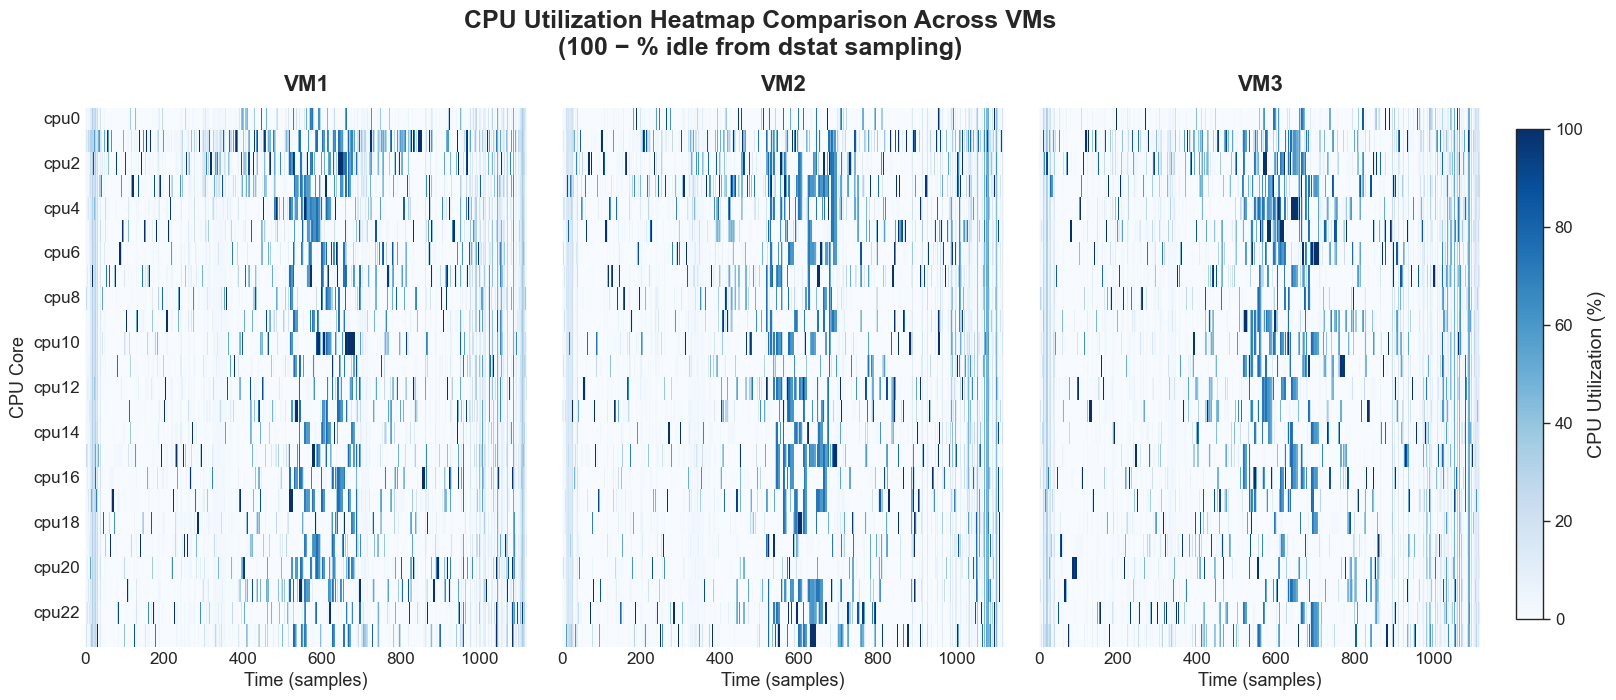

In [15]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# ───────────────────────────────────────────────
# Parser function (same reliable one)
# ───────────────────────────────────────────────
def parse_dstat_util(filename):
    data = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.rstrip()
            if not line or line.startswith(('You did', '-----', 'usr sys')):
                continue
            if '|' in line:
                line = line.split('|', 1)[0]
            matches = re.findall(r'\d+\s+\d+\s+\d+\s+\d+\s+\d+', line)
            if not matches:
                continue
            idls = [int(re.split(r'\s+', g.strip())[2]) for g in matches]
            if idls:
                data.append(idls)
    if not data:
        raise ValueError(f"No valid data parsed from {filename}")
    n_cpus = len(data[0])
    df_idl = pd.DataFrame(data, columns=[f"cpu{i}" for i in range(n_cpus)])
    df_util = 100 - df_idl.astype(float)  # ensure float for plotting
    return df_util, n_cpus

# ───────────────────────────────────────────────
# Load all three files
# ───────────────────────────────────────────────
files = {
    'VM1': 'vm1-report_cpu.out',     # ← change filenames if different
    'VM2': 'vm2-report_cpu.out',
    'VM3': 'vm3-report_cpu.out'
}

results = {}
max_cores = 0
for label, fname in files.items():
    try:
        df_u, n = parse_dstat_util(fname)
        results[label] = df_u
        max_cores = max(max_cores, n)
        print(f"{label}: {df_u.shape[0]:,} samples × {n} cores")
    except Exception as e:
        print(f"Error loading {label}: {e}")

if not results:
    raise ValueError("No files could be parsed")

# ───────────────────────────────────────────────
# Publication-quality 3-panel heatmap
# ───────────────────────────────────────────────
sns.set_context("paper", font_scale=1.4)
sns.set_style("white")

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 7), 
                         sharey=True, gridspec_kw={'wspace': 0.08})

# Nice perceptually uniform colormap: low=light, high=dark red
cmap = LinearSegmentedColormap.from_list("util", ["#f7fbff", "#deebf7", "#c6dbef", "#9ecae1", "#6baed6", "#4292c6", "#2171b5", "#08519c", "#08306b"])

vmin, vmax = 0, 100

for ax, (label, df) in zip(axes, results.items()):
    # Transpose so time = x, cores = y
    sns.heatmap(df.T, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                cbar=False, xticklabels=200, yticklabels=2 if df.shape[1] <= 32 else False,
                rasterized=True, linewidths=0)
    
    ax.set_title(label, fontsize=16, pad=12, fontweight='bold')
    ax.set_xlabel("Time (samples)", fontsize=13)
    ax.set_ylabel("CPU Core" if ax == axes[0] else "", fontsize=13)
    
    # Minor ticks off for cleaner look
    ax.tick_params(axis='both', which='both', length=0)

# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
norm = plt.Normalize(vmin, vmax)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label("CPU Utilization (%)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Overall title
fig.suptitle("CPU Utilization Heatmap Comparison Across VMs\n(100 − % idle from dstat sampling)", 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0, 0.90, 1.0])  # leave space for colorbar

# High-quality export
plt.savefig("cpu_util_heatmap_three_vms.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig("cpu_util_heatmap_three_vms.pdf", bbox_inches='tight', facecolor='white')

plt.show()